In [1]:
from datasets import load_dataset
import re
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import os

In [2]:
def set_seed(seed_value=42):
    """Set seeds for reproducibility across Python, NumPy, and PyTorch."""
    # 1. Python built-in random module
    random.seed(seed_value)
    
    # 2. NumPy
    np.random.seed(seed_value)
    
    # 3. PyTorch (for CPU and GPU)
    torch.manual_seed(seed_value)
    
    if torch.cuda.is_available():
        # Set seed for all available GPUs
        torch.cuda.manual_seed_all(seed_value)
        # Recommended for deterministic behavior on GPUs, though it may slow things down
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    # Optional: Set environment variable for system-wide reproducibility
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    print(f"Global seed set to {seed_value}")

# Call the function early in your script before any data loading or model initialization
set_seed(42)

Global seed set to 42


The following dataset is a well-known dataset often used for **Named Entity Recognition (NER)**, **Part-of-Speech (POS) tagging**, and **shallow parsing/chunking**.

In [3]:
raw_datasets = load_dataset("lhoestq/conll2003")
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

<h4> Dataset Splits </h4>

The dataset ("lhoestq/conll2003") is divided into three standard splits:

* **`train`**: Contains **14,041** examples, used for model training.
* **`validation`**: Contains **3,250** examples, used for hyperparameter tuning and evaluation during training.
* **`test`**: Contains **3,453** examples, used for final, unbiased model evaluation.

---

<h4> Dataset Features (Parameters) </h4>

Each example (sentence/row) in the dataset includes the following features for sequence labeling tasks:

* **`id`**: A unique identifier for the sequence.
* **`tokens`**: A **sequence of strings** representing the individual words in the sentence.
* **`pos_tags`**: A **sequence of integers** representing the **Part-of-Speech (POS) tag** for each token (e.g., Noun, Verb).
* **`chunk_tags`**: A **sequence of integers** representing the **chunk tag** (or shallow parse tag) for each token (e.g., Noun Phrase, Verb Phrase).
* **`ner_tags`**: A **sequence of integers** representing the **Named Entity Recognition (NER) tag** for each token (e.g., Person, Location, Organization).

In [4]:
ner_feature = raw_datasets["train"].features["ner_tags"]
ner_feature

List(Value('int64'))

| Number | Tag    | Tag | Meaning               |
| ------ | ------ | --- | --------------------- |
| 0      | O      | B-  | start of entity       |
| 1      | B-PER  | I-  | inside entity         |
| 2      | I-PER  | O   | outside (normal word) |
| 3      | B-ORG  | PER  | Person               |
| 4      | I-ORG  | LOC  | Location                                                          |
| 5      | B-LOC  | ORG  | Organization                                                      |
| 6      | I-LOC  | MISC | Miscellaneous (entities that don't fit in the other 3 categories) |
| 7      | B-MISC |
| 8      | I-MISC |



In [5]:
sentences = []
for split in ['train', 'validation', 'test']:
    for item in raw_datasets[split]:
        sentences.append(' '.join(item['tokens'])) # joined the tokens/strings
        # we can do that here because our goal is to just create the word embeddings but in Part 2,
        # we will be needing the tokens individually

In [6]:
len(sentences)

20744

In [113]:
# def preprocess(text):
#     text = text.lower()
#     text = re.sub(r"[^a-z0-9 ]", "", text)
#     return text # do we need tokenization? 

In [114]:
# corpus = [preprocess(sent) for sent in sentences] # preprocess each sentence
# print(len(corpus))
# print(corpus[0])
# words = [w for sent in corpus for w in sent] # get all the words -- not unique list
# print(len(words)) # w is not a word but list of characters :(
# print(words[0])
# vocab = Counter(words) # dictionary of unique words
# print(len(vocab)) 
# vocab = {w: i for i, (w, _) in enumerate(vocab.items())}
# inv_vocab = {i: w for w, i in vocab.items()}

In [115]:
# print(preprocess("The cats are running quickly!"))
# print(sentences[:10])

In [7]:
def preprocess(text):
    text = text.lower()
    # Replace non-alphanumeric characters (excluding spaces) with an empty string
    text = re.sub(r"[^a-z0-9 ]", "", text) 
    
    return text.split()

In [8]:
corpus = [preprocess(sent) for sent in sentences] # preprocess each sentence
print(len(corpus))
print(corpus[0])
words = [w for sent in corpus for w in sent] # get all the words -- not unique list
print(len(words)) # w is now a word
print(words[0])
vocab = Counter(words) # dictionary of unique words -- WORD: COUNT OF WORD
print(len(vocab)) 
print(vocab['boy'])
vocab = {w: i for i, (w, _) in enumerate(vocab.items())} # vocab now is WORD : INDEX
inv_vocab = {i: w for w, i in vocab.items()} # INDEX : WORD

print(len(vocab))
print(inv_vocab[25527])

20744
['eu', 'rejects', 'german', 'call', 'to', 'boycott', 'british', 'lamb']
263042
eu
25528
19
25528
wellfancied


In [9]:
print(preprocess(f"{sentences[0]}"))
print(sentences[0])
print(sentences[:10])

['eu', 'rejects', 'german', 'call', 'to', 'boycott', 'british', 'lamb']
EU rejects German call to boycott British lamb .
['EU rejects German call to boycott British lamb .', 'Peter Blackburn', 'BRUSSELS 1996-08-22', 'The European Commission said on Thursday it disagreed with German advice to consumers to shun British lamb until scientists determine whether mad cow disease can be transmitted to sheep .', "Germany 's representative to the European Union 's veterinary committee Werner Zwingmann said on Wednesday consumers should buy sheepmeat from countries other than Britain until the scientific advice was clearer .", '" We do n\'t support any such recommendation because we do n\'t see any grounds for it , " the Commission \'s chief spokesman Nikolaus van der Pas told a news briefing .', 'He said further scientific study was required and if it was found that action was needed it should be taken by the European Union .', 'He said a proposal last month by EU Farm Commissioner Franz Fischle

In [10]:
window_size = 11 # 5 words left the target and 5 words right # 10 also works but makes no sense
training_pairs = [] # these are the positive examples. 
for sent in corpus: # sent is a list of words
    for i, word in enumerate(sent): 
        target = vocab[word] # an index
        for j in range(max(0, i-window_size//2), min(len(sent), i+window_size//2)):
            if i!=j:
                context = vocab[sent[j]] # an index
                training_pairs.append((target, context))    # pair of word_ids/INDICES of positive samples (unrelated to the dataset ids)

In [11]:
print(len(training_pairs))
print(training_pairs[:10])

1878509
[(0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 2), (1, 3), (1, 4), (1, 5), (2, 0)]


In [12]:
# In Negative Sampling we are trying to create pairs that did not appear together.
# The problem is the vocabulary has too many words.
# For a positive pair there are too many negative examples. Checking all of them is way too slow.
# so we'll just randomly pick K bad words you will use it in training to get pairs labeled 0

word_freq = torch.tensor([freq for _, freq in Counter(words).items()], dtype=torch.float)
neg_dist = word_freq ** 0.75 # smoothing
neg_dist = neg_dist / neg_dist.sum() # normalization


# def get_negative_samples(context, K):
#     neg = []
#     while len(neg) < K:
#         sample = torch.multinomial(neg_dist, 1).item()
#         if sample != context.item(): # context is the positive words
#             neg.append(sample)
#     return torch.tensor(neg)  # a tensor of bad words for the target of shape (,K)

<h4>💡 Why this approach is necessary </h4>
Negative sampling is a dynamic process (it's random). By generating new negative samples for every batch, you expose the model to a wider variety of negative examples, which improves the quality of the learned embeddings. If you pre-calculated and saved the negative samples, they would be static and less effective.

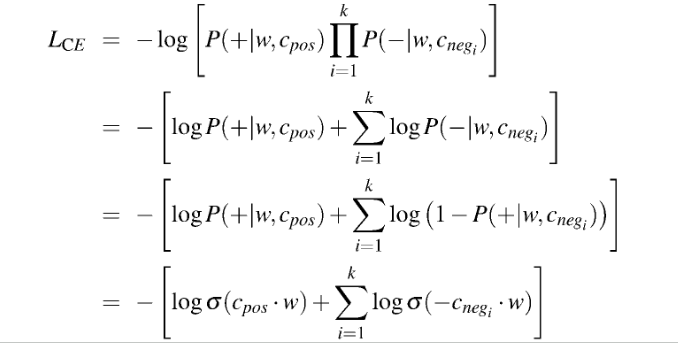
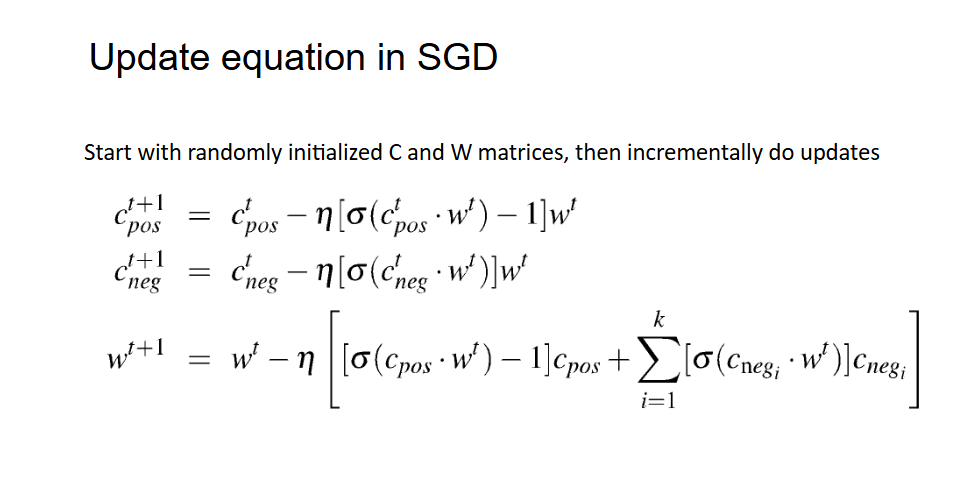
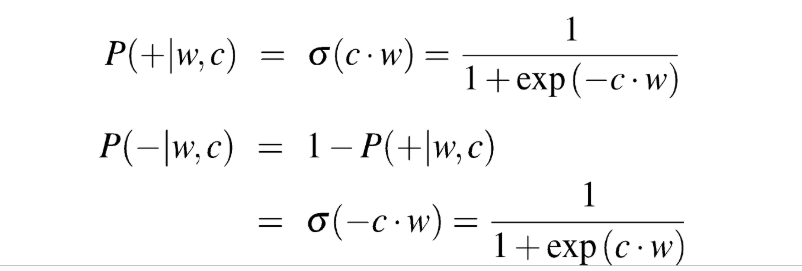

In [13]:
class SGNS(nn.Module):
    def __init__(self, vocab_size, embed_dim=100):
        super().__init__()
        # two sets of embeddings
        self.target_embed = nn.Embedding(vocab_size, embed_dim)
        self.context_embed = nn.Embedding(vocab_size, embed_dim)
    def forward(self, target, context, neg_samples):
        # calculate P(+|w,c) and P(-|w,c) 
        
        # --- 1. Get Embeddings ---
        # v_t: Target (center) vector
        target_vec = self.target_embed(target).unsqueeze(1)       # Shape: (B, 1, D) if target is (B, 1)
        
        # u_c: Positive context vector
        context_vec = self.context_embed(context).unsqueeze(1)    # Shape: (B, 1, D) if context is (B, 1)
        
        # U_n: Negative sample vectors
        neg_vecs = self.context_embed(neg_samples)  # Shape: (B, K, D)
        
        
        # --- 2. Positive Pair Calculation (P(+|w,c)) ---
        
        # Calculate v_t * u_c^T (Positive Score)
        # Using bmm for batched dot product, assuming target_vec is (B, 1, D) and context_vec is (B, 1, D)
        # torch.bmm((B, 1, D), (B, D, 1)) -> (B, 1, 1)
        
        pos_scores = torch.bmm(target_vec, context_vec.transpose(1, 2)).squeeze(-1)
        # Resulting pos_scores shape: (B, 1) or (B)
        
        # --- 3. Negative Pairs Calculation (P(-|w,n)) ---
        
        # Calculate v_t * U_n^T (Negative Scores)
        # torch.bmm((B, 1, D), (B, D, K)) -> (B, 1, K)
        neg_scores = torch.bmm(target_vec, neg_vecs.transpose(1, 2)).squeeze(1)
        # Resulting neg_scores shape: (B, K)
        
        
        # --- 4. Compute Loss using Sigmoid (Binary Cross-Entropy) ---
        
        # Loss for positive pair: -log(P(+|w,c)) = -log(sigmoid(v_t * u_c^T))
        # Note: F.logsigmoid is numerically stable. We don't need the negative sign 
        # because the term F.logsigmoid(pos_scores) is already negative.
        pos_loss = -F.logsigmoid(pos_scores).mean()
        
        # Loss for negative pairs: -log(P(-|w,n)) = -log(1 - sigmoid(v_t * u_n^T))
        # From the math: 1 - sigmoid(x) = sigmoid(-x)
        # Loss: sum(-log(sigmoid(-v_t * u_n^T))) / (B*K)
        
        neg_loss = -F.logsigmoid(-neg_scores).mean()
        
        
        # --- 5. Total Loss ---
        total_loss = pos_loss + neg_loss
        
        return total_loss

In [14]:
class Word2VecDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        return self.pairs[idx]

In [15]:
def generate_batch_neg_samples(context_indices, neg_dist, K):
    """
    Generates K negative samples for every item in the batch.
    
    Args:
        context_indices (torch.Tensor): The indices of the positive context words (B,).
        neg_dist (torch.Tensor): The normalized probability distribution for sampling (V,).
        K (int): The number of negative samples per positive pair.
        
    Returns:
        torch.Tensor: A tensor of negative sample indices (B, K).
    """
    batch_size = context_indices.size(0)
    vocab_size = neg_dist.size(0)
    
    # 1. Generate B * K candidate samples
    # torch.multinomial samples from neg_dist (V,) with replacement, B*K times
    # Resulting shape: (B * K)
    neg_samples_flat = torch.multinomial(
        neg_dist, 
        num_samples=batch_size * K, 
        replacement=True
    )
    
    # Reshape to (B, K)
    neg_samples = neg_samples_flat.view(batch_size, K)
    
    # 2. Check and replace samples that are the same as the positive context
    # This comparison and replacement is done to prevent a sampled negative word 
    # from being the actual positive context word.
    
    # Reshape context_indices to (B, K) for element-wise comparison
    context_repeated = context_indices.unsqueeze(1).repeat(1, K)
    
    # Create a mask: True where the sample == context
    mask = (neg_samples == context_repeated)
    
    # While there are still samples to replace (at least one True in the mask)
    while mask.any():
        # Generate new replacement samples only for the masked positions
        replacement_samples = torch.multinomial(
            neg_dist, 
            num_samples=mask.sum().item(), 
            replacement=True
        ).to(neg_samples.device) # Ensure device consistency
        
        # Insert new samples only where the mask is True
        neg_samples[mask] = replacement_samples
        
        # Recalculate the mask to ensure the new samples aren't equal to context
        mask = (neg_samples == context_repeated)
        
    return neg_samples

# --- How to call it in your training loop ---
# Note: You need to pass the pre-calculated neg_dist tensor
# neg_samples_indices = generate_batch_neg_samples(context_indices, neg_dist, K)

In [16]:
# --- Setup ---
K = 10  # Number of negative samples per positive pair
EPOCHS = 20 
vocab_size = len(vocab)
sgns_model = SGNS(vocab_size, embed_dim=300) # Instantiate your model
optimizer = optim.Adam(sgns_model.parameters(), lr=0.001) # Choose an optimizer
train_loader = DataLoader(Word2VecDataset(training_pairs), batch_size=1024, shuffle=True)

In [17]:
# --- Training Loop ---
for epoch in range(EPOCHS):
    total_epoch_loss = 0
    
    for i, (target_indices, context_indices) in enumerate(train_loader):
        
        # 0. Zero the gradients
        optimizer.zero_grad() 
        
        # 1. Get Negative Samples (Crucial step outside forward)
        # Note: You need a robust function to generate a (B, K) tensor of negative indices
        neg_samples = generate_batch_neg_samples(context_indices,neg_dist, K) 
        
        # 2. Forward Pass
        # The forward method you implemented computes the loss!
        loss = sgns_model(target_indices, context_indices, neg_samples)
        
        # 3. Backward Pass (Calculating Gradients)
        loss.backward() # need not to be implemented?
        
        # 4. Optimization Step (Updating Weights/Embeddings)
        optimizer.step()
        
        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}')



Epoch 1/20, Loss: 11.0050
Epoch 2/20, Loss: 7.6631


KeyboardInterrupt: 

In [ ]:
# --- Saving Embeddings ---
# After training, you will save the learned embeddings[cite: 24].
word_embeddings = sgns_model.target_embed.weight.data 
torch.save(word_embeddings, 'word2vec_embeddings.pt')
torch.save(vocab, "vocab_list.pt")

In [128]:
def word_analogy(word_embeddings, vocab, inv_vocab, word_a, word_b, word_a_star, K_closest=1):
    """
    Solves the analogy problem: A is to B as A* is to B*
    
    Args:
        word_embeddings (torch.Tensor): The V x D target embedding matrix.
        vocab (dict): Word-to-Index mapping.
        inv_vocab (dict): Index-to-Word mapping.
        word_a (str): Word A (e.g., 'man').
        word_b (str): Word B (e.g., 'king').
        word_a_star (str): Word A* (e.g., 'woman').
        K_closest (int): Number of closest words to return.
        
    Returns:
        list: The top K predicted words for B*.
    """
    
    # --- 1. Get Indices ---
    if word_a not in vocab or word_b not in vocab or word_a_star not in vocab:
        return "One or more input words not found in vocabulary."

    a_idx = vocab[word_a]
    b_idx = vocab[word_b]
    a_star_idx = vocab[word_a_star]
    
    # --- 2. Get Vectors ---
    # Retrieve the D-dimensional embedding vectors
    vec_a = word_embeddings[a_idx]
    vec_b = word_embeddings[b_idx]
    vec_a_star = word_embeddings[a_star_idx]
    
    # --- 3. Compute Resulting Vector (B - A + A*) ---
    # Shape of result_vec: (D,)
    result_vec = vec_b - vec_a + vec_a_star
    
    # --- 4. Calculate Cosine Similarity to All Words ---
    # Normalize all embeddings (for cosine similarity via dot product)
    # Cosine Similarity is defined as (A . B) / (||A|| * ||B||)
    # F.normalize computes ||A|| / ||A||. We do not need the target word
    # in the similarity calculation, so we remove its vector.
    
    # Normalize the result vector
    result_vec_norm = F.normalize(result_vec.unsqueeze(0), p=2, dim=-1) # Shape: (1, D)

    # Normalize all word embeddings
    all_embeddings_norm = F.normalize(word_embeddings, p=2, dim=-1) # Shape: (V, D)

    # Calculate similarity: (1, D) @ (D, V) -> (1, V)
    similarity_scores = torch.matmul(result_vec_norm, all_embeddings_norm.T).squeeze(0) # Shape: (V)

    # --- 5. Exclude Input Words from Results ---
    # Set the similarity scores of the input words to a very low value so they are not picked
    similarity_scores[a_idx] = -float('inf')
    similarity_scores[b_idx] = -float('inf')
    similarity_scores[a_star_idx] = -float('inf')
    
    # --- 6. Find Top K Indices and Words ---
    # torch.topk returns values and indices of the K largest elements
    top_k_values, top_k_indices = torch.topk(similarity_scores, K_closest)
    
    # Convert indices back to words
    predicted_words = [inv_vocab[idx.item()] for idx in top_k_indices]
    
    return predicted_words

# Example usage (assuming your variables are defined):
B_star = word_analogy(word_embeddings, vocab, inv_vocab, 'man', 'king', 'woman', K_closest=5)
print(f"man is to king as woman is to: {B_star}")

man is to king as woman is to: ['result', 'finally', 'montserrat', 'passes', 'overhead']
